In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK 1 · Data Import & Format Conversion
# ═══════════════════════════════════════════════════════════════════════════════
import os
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

DATASET_DIR   = r"dataset"
PROCESSED_DIR = os.path.join(DATASET_DIR, "processed")
TARGET_SIZE   = (224, 224)   # standard resolution for model compatibility

# Re-read CSV with original relative filepaths
df_raw = pd.read_csv(os.path.join(DATASET_DIR, "sports.csv"))
print(f"Total entries in CSV : {len(df_raw):,}")
print(f"Target format        : JPEG  |  Target size : {TARGET_SIZE[0]}×{TARGET_SIZE[1]} px\n")

records = []

for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc="Converting & Resizing"):
    rel_path = row["filepaths"]                          # e.g. "train/air hockey/001.jpg"
    src_path = os.path.join(DATASET_DIR, rel_path)
    label    = row["labels"]
    split    = row["data set"]
    filename = os.path.basename(rel_path)

    # Mirror original structure inside processed/  →  processed/<split>/<label>/<file>.jpg
    out_dir  = os.path.join(PROCESSED_DIR, split, label)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, os.path.splitext(filename)[0] + ".jpg")

    try:
        with Image.open(src_path) as img:
            orig_w, orig_h = img.size
            orig_fmt       = img.format or "UNKNOWN"
            # Convert to RGB (handles RGBA/palette PNGs) then resize
            img.convert("RGB").resize(TARGET_SIZE, Image.LANCZOS).save(
                out_path, format="JPEG", quality=95
            )
        records.append(dict(
            class_id=row["class id"], label=label, split=split,
            processed_path=out_path, original_filepath=src_path,
            original_width=orig_w, original_height=orig_h,
            original_format=orig_fmt, status="ok"
        ))
    except Exception as e:
        records.append(dict(
            class_id=row["class id"], label=label, split=split,
            processed_path=None, original_filepath=src_path,
            original_width=None, original_height=None,
            original_format=None, status=f"error: {e}"
        ))

df_proc = pd.DataFrame(records)

ok_n  = (df_proc["status"] == "ok").sum()
err_n = len(df_proc) - ok_n
print(f"\n✅ Successfully converted & resized : {ok_n:,}")
print(f"❌ Failed (corrupt / missing)       : {err_n:,}")
print(f"📁 Output directory                 : {PROCESSED_DIR}")
display(df_proc.head())


Total entries in CSV : 14,493
Target format        : JPEG  |  Target size : 224×224 px



Converting & Resizing: 100%|██████████| 14493/14493 [00:59<00:00, 244.01it/s]



✅ Successfully converted & resized : 14,492
❌ Failed (corrupt / missing)       : 1
📁 Output directory                 : dataset\processed


,class_id,label,split,processed_path,original_filepath,original_width,original_height,original_format,status
0,0,air hockey,train,dataset\processed\train\air hockey\001.jpg,dataset\train/air hockey/001.jpg,224.0,224.0,JPEG,ok
1,0,air hockey,train,dataset\processed\train\air hockey\002.jpg,dataset\train/air hockey/002.jpg,224.0,224.0,JPEG,ok
2,0,air hockey,train,dataset\processed\train\air hockey\003.jpg,dataset\train/air hockey/003.jpg,224.0,224.0,JPEG,ok
3,0,air hockey,train,dataset\processed\train\air hockey\004.jpg,dataset\train/air hockey/004.jpg,224.0,224.0,JPEG,ok
4,0,air hockey,train,dataset\processed\train\air hockey\005.jpg,dataset\train/air hockey/005.jpg,224.0,224.0,JPEG,ok


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK 2 · Metadata & Data Cleaning
# ═══════════════════════════════════════════════════════════════════════════════
import numpy as np

DATASET_DIR = r"dataset"
MIN_DIM     = 100   # original images smaller than 100×100 px are low-res noise

# ── Start from successfully processed images ──────────────────────────────────
df_clean = df_proc[df_proc["status"] == "ok"].copy().reset_index(drop=True)
print(f"Starting pool          : {len(df_clean):,} images")

# ── 2a. Remove corrupt images (already flagged in Task 1) ────────────────────
n_corrupt = (df_proc["status"] != "ok").sum()
print(f"Corrupt images removed : {n_corrupt:,}")

# ── 2b. Remove low-resolution originals (< 100×100 px) ───────────────────────
low_res_mask = (
    (df_clean["original_width"]  < MIN_DIM) |
    (df_clean["original_height"] < MIN_DIM)
)
n_low_res = low_res_mask.sum()
df_clean  = df_clean[~low_res_mask].reset_index(drop=True)
print(f"Low-res images removed : {n_low_res:,}  (original size < {MIN_DIM}×{MIN_DIM} px)")

# ── 2c. Outlier Detection via pixel statistics ────────────────────────────────
# Flags:  too dark  (mean < 10)  |  overexposed (mean > 245)  |  uniform (std < 5)
print("\nComputing per-image pixel statistics for outlier detection …")

def img_stats(path):
    try:
        arr = np.asarray(Image.open(path).convert("RGB"), dtype=np.float32)
        return float(arr.mean()), float(arr.std())
    except Exception:
        return None, None

stats_list = [img_stats(p) for p in tqdm(df_clean["processed_path"], desc="Pixel stats")]
df_clean["pixel_mean"], df_clean["pixel_std"] = zip(*stats_list)

outlier_mask = (
    df_clean["pixel_mean"].isna()       |     # unreadable after processing
    (df_clean["pixel_mean"] <  10.0)   |     # nearly black — unusable
    (df_clean["pixel_mean"] > 245.0)   |     # overexposed / blank white
    (df_clean["pixel_std"]  <   5.0)         # solid colour / logo / static
)
n_outliers = outlier_mask.sum()
df_clean   = df_clean[~outlier_mask].reset_index(drop=True)
print(f"Statistical outliers removed : {n_outliers:,}  "
      f"(too dark / overexposed / uniform)")

print(f"\n✅ Clean dataset : {len(df_clean):,} images  |  "
      f"{df_clean['label'].nunique()} unique classes")

# ── 2d. Generate metadata.csv ─────────────────────────────────────────────────
META_COLS    = ["class_id", "label", "split", "processed_path",
                "original_filepath", "original_width", "original_height",
                "original_format", "pixel_mean", "pixel_std"]
metadata_csv = os.path.join(DATASET_DIR, "metadata.csv")
df_clean[META_COLS].to_csv(metadata_csv, index=False)
print(f"📄 metadata.csv saved → {metadata_csv}")

display(df_clean[META_COLS].head())


Starting pool          : 14,492 images
Corrupt images removed : 1
Low-res images removed : 0  (original size < 100×100 px)

Computing per-image pixel statistics for outlier detection …


Pixel stats: 100%|██████████| 14492/14492 [00:31<00:00, 462.85it/s]


Statistical outliers removed : 3  (too dark / overexposed / uniform)

✅ Clean dataset : 14,489 images  |  100 unique classes
📄 metadata.csv saved → dataset\metadata.csv


,class_id,label,split,processed_path,original_filepath,original_width,original_height,original_format,pixel_mean,pixel_std
0,0,air hockey,train,dataset\processed\train\air hockey\001.jpg,dataset\train/air hockey/001.jpg,224.0,224.0,JPEG,127.062485,60.315140
1,0,air hockey,train,dataset\processed\train\air hockey\002.jpg,dataset\train/air hockey/002.jpg,224.0,224.0,JPEG,51.475559,65.461243
2,0,air hockey,train,dataset\processed\train\air hockey\003.jpg,dataset\train/air hockey/003.jpg,224.0,224.0,JPEG,70.292038,68.124985
3,0,air hockey,train,dataset\processed\train\air hockey\004.jpg,dataset\train/air hockey/004.jpg,224.0,224.0,JPEG,70.580467,70.075531
4,0,air hockey,train,dataset\processed\train\air hockey\005.jpg,dataset\train/air hockey/005.jpg,224.0,224.0,JPEG,122.629395,62.485626


=== Class Distribution BEFORE Balancing ===
  Max    : 201  →  football
  Min    : 69  →  sky surfing
  Median : 144
  Classes with > 500 samples : 0
  Classes with < 300 samples  : 100

After undersampling  (max 500/class) : 14,489 images
Minority classes to augment        : 100


Augmenting minority classes: 100%|██████████| 100/100 [00:57<00:00,  1.74it/s]



After augmentation   (min 300/class) : 30,000 images
  Max    : 300
  Min    : 300
  Median : 300


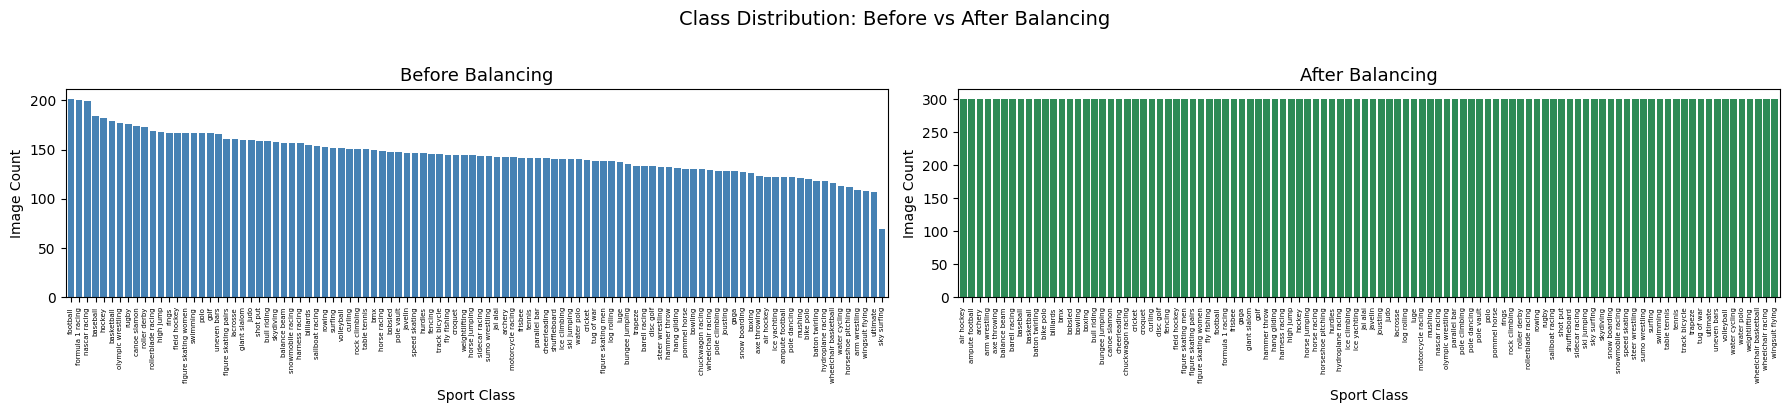

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK 3 · Data Balancing  (Undersampling + Augmentation)
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from PIL import ImageEnhance, ImageOps

DATASET_DIR     = r"dataset"
AUG_DIR         = os.path.join(DATASET_DIR, "augmented")
os.makedirs(AUG_DIR, exist_ok=True)

UNDERSAMPLE_MAX = 500   # cap majority classes at this count
OVERSAMPLE_MIN  = 300   # augment minority classes up to this count

# ── Distribution BEFORE balancing ────────────────────────────────────────────
counts_before = df_clean.groupby("label").size().sort_values(ascending=False)
print("=== Class Distribution BEFORE Balancing ===")
print(f"  Max    : {counts_before.max():,}  →  {counts_before.idxmax()}")
print(f"  Min    : {counts_before.min():,}  →  {counts_before.idxmin()}")
print(f"  Median : {counts_before.median():.0f}")
print(f"  Classes with > {UNDERSAMPLE_MAX} samples : "
      f"{(counts_before > UNDERSAMPLE_MAX).sum()}")
print(f"  Classes with < {OVERSAMPLE_MIN} samples  : "
      f"{(counts_before < OVERSAMPLE_MIN).sum()}")

# ── 3a. Undersampling majority classes ───────────────────────────────────────
df_under = (
    df_clean
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), UNDERSAMPLE_MAX), random_state=42))
    .reset_index(drop=True)
)
print(f"\nAfter undersampling  (max {UNDERSAMPLE_MAX}/class) : {len(df_under):,} images")

# ── 3b. Augmentation for minority classes ────────────────────────────────────
# Six deterministic transforms — cycled until the target count is reached
AUGMENTATIONS = [
    ("hflip",      lambda i: ImageOps.mirror(i)),
    ("rot_p15",    lambda i: i.rotate( 15, expand=False, fillcolor=(128, 128, 128))),
    ("rot_n15",    lambda i: i.rotate(-15, expand=False, fillcolor=(128, 128, 128))),
    ("bright_up",  lambda i: ImageEnhance.Brightness(i).enhance(1.3)),
    ("bright_dn",  lambda i: ImageEnhance.Brightness(i).enhance(0.7)),
    ("contrast",   lambda i: ImageEnhance.Contrast(i).enhance(1.4)),
]

minority_labels = (
    df_under.groupby("label").size()
    .loc[lambda s: s < OVERSAMPLE_MIN]
    .index.tolist()
)
print(f"Minority classes to augment        : {len(minority_labels)}")

aug_records = []
for label in tqdm(minority_labels, desc="Augmenting minority classes"):
    grp       = df_under[df_under["label"] == label]
    current_n = len(grp)
    needed    = OVERSAMPLE_MIN - current_n

    out_dir = os.path.join(AUG_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    for aug_idx in range(needed):
        src_row         = grp.iloc[aug_idx % current_n]
        aug_name, aug_fn = AUGMENTATIONS[aug_idx % len(AUGMENTATIONS)]
        out_path        = os.path.join(out_dir, f"aug_{aug_idx:04d}_{aug_name}.jpg")
        try:
            with Image.open(src_row["processed_path"]) as img:
                aug_fn(img.convert("RGB")).save(out_path, format="JPEG", quality=95)
            aug_records.append(dict(
                class_id=src_row["class_id"], label=label, split="augmented",
                processed_path=out_path,
                original_filepath=src_row["original_filepath"],
                original_width=src_row["original_width"],
                original_height=src_row["original_height"],
                original_format="JPEG", pixel_mean=None, pixel_std=None
            ))
        except Exception:
            pass   # skip individual augmentation failures

df_aug      = pd.DataFrame(aug_records)
df_balanced = pd.concat([df_under, df_aug], ignore_index=True)

counts_after = df_balanced.groupby("label").size().sort_values(ascending=False)
print(f"\nAfter augmentation   (min {OVERSAMPLE_MIN}/class) : {len(df_balanced):,} images")
print(f"  Max    : {counts_after.max():,}")
print(f"  Min    : {counts_after.min():,}")
print(f"  Median : {counts_after.median():.0f}")

# ── Visualise before / after ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
counts_before.plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_title("Before Balancing", fontsize=13)
axes[0].set_xlabel("Sport Class")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis="x", labelsize=5, rotation=90)

counts_after.plot(kind="bar", ax=axes[1], color="seagreen", width=0.8)
axes[1].set_title("After Balancing", fontsize=13)
axes[1].set_xlabel("Sport Class")
axes[1].set_ylabel("Image Count")
axes[1].tick_params(axis="x", labelsize=5, rotation=90)

plt.suptitle("Class Distribution: Before vs After Balancing", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


╔══════════════════════════════════════════════════════════╗
║           Final Stratified Split Summary                 ║
╠══════════════════════════════════════════════════════════╣
║  Train  (70%) :  21,000 images  ( 70.0%)  |  100 classes  ║
║  Valid  (15%) :   4,500 images  ( 15.0%)  |  100 classes  ║
║  Test   (15%) :   4,500 images  ( 15.0%)  |  100 classes  ║
╚══════════════════════════════════════════════════════════╝

💾 Split CSVs saved → dataset\splits
    train.csv  |  valid.csv  |  test.csv

=== Per-class Stratification Check (first 10 classes) ===


split,test,train,valid,total,train%,valid%,test%
label,,,,,,,
air hockey,45,210,45,300,70.0,15.0,15.0
ampute football,45,210,45,300,70.0,15.0,15.0
archery,45,210,45,300,70.0,15.0,15.0
arm wrestling,45,210,45,300,70.0,15.0,15.0
axe throwing,45,210,45,300,70.0,15.0,15.0
balance beam,45,210,45,300,70.0,15.0,15.0
barell racing,45,210,45,300,70.0,15.0,15.0
baseball,45,210,45,300,70.0,15.0,15.0
basketball,45,210,45,300,70.0,15.0,15.0


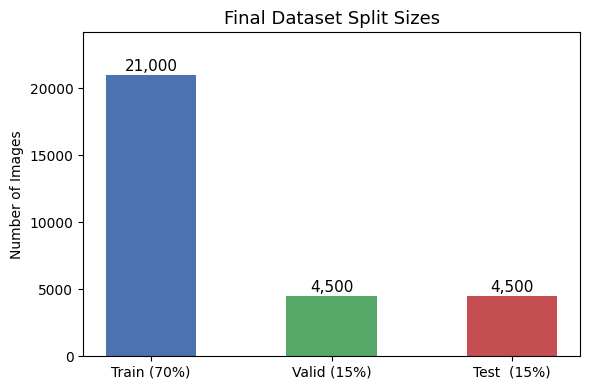

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK 4 · Stratified Data Splitting  (70% Train | 15% Valid | 15% Test)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

DATASET_DIR = r"dataset"
SPLITS_DIR  = os.path.join(DATASET_DIR, "splits")
os.makedirs(SPLITS_DIR, exist_ok=True)

X = df_balanced.copy()
y = X["label"].values

# ── Step 1 : 70% train  /  30% temp ──────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ── Step 2 : 50% of temp → valid (15%)  |  50% → test (15%) ──────────────────
X_valid, X_test, _, _ = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# ── Assign split labels & save CSVs ──────────────────────────────────────────
split_map = {"train": X_train, "valid": X_valid, "test": X_test}
for name, subset in split_map.items():
    out = subset.copy()
    out["split"] = name
    out.to_csv(os.path.join(SPLITS_DIR, f"{name}.csv"), index=False)

# ── Summary table ─────────────────────────────────────────────────────────────
total = len(X)
print("╔══════════════════════════════════════════════════════════╗")
print("║           Final Stratified Split Summary                 ║")
print("╠══════════════════════════════════════════════════════════╣")
rows = [("Train  (70%)", X_train), ("Valid  (15%)", X_valid), ("Test   (15%)", X_test)]
for name, subset in rows:
    n = len(subset)
    print(f"║  {name} :  {n:>6,} images  ({n/total*100:5.1f}%)  "
          f"|  {subset['label'].nunique()} classes  ║")
print("╚══════════════════════════════════════════════════════════╝")
print(f"\n💾 Split CSVs saved → {SPLITS_DIR}")
print("    train.csv  |  valid.csv  |  test.csv")

# ── Per-class stratification check ───────────────────────────────────────────
df_check = pd.concat([
    X_train.assign(split="train"),
    X_valid.assign(split="valid"),
    X_test.assign(split="test"),
])
strat = df_check.groupby(["label", "split"]).size().unstack(fill_value=0)
strat["total"]   = strat.sum(axis=1)
strat["train%"]  = (strat["train"] / strat["total"] * 100).round(1)
strat["valid%"]  = (strat["valid"] / strat["total"] * 100).round(1)
strat["test%"]   = (strat["test"]  / strat["total"] * 100).round(1)

print("\n=== Per-class Stratification Check (first 10 classes) ===")
display(strat.head(10))

# ── Bar chart of final split sizes ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
split_sizes = {"Train (70%)": len(X_train),
               "Valid (15%)": len(X_valid),
               "Test  (15%)": len(X_test)}
colors = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(split_sizes.keys(), split_sizes.values(), color=colors, width=0.5)
for bar, val in zip(bars, split_sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontsize=11)
ax.set_title("Final Dataset Split Sizes", fontsize=13)
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(split_sizes.values()) * 1.15)
plt.tight_layout()
plt.show()
